Brain Tumour Segmentation in MRI with U-Net.

In [2]:
!pip install -q segmentation-models-pytorch kagglehub

import torch
print("GPU available:", torch.cuda.is_available())

from google.colab import drive
drive.mount("/content/drive")


GPU available: True
Mounted at /content/drive


In [3]:
import kagglehub, glob, os

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
print("Downloaded to:", path)

# List all masks, and remove duplicate copies of the same file
mask_files = glob.glob(os.path.join(path, "**", "*_mask.tif"), recursive=True)
unique = {}
for m in mask_files:
    unique.setdefault(os.path.basename(m), m)
mask_files = sorted(unique.values())

# For each mask, find its image and its patient
image_files = [m.replace("_mask.tif", ".tif") for m in mask_files]
patients = [os.path.basename(os.path.dirname(m)) for m in mask_files]

print(len(image_files), "slices from", len(set(patients)), "patients")

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Downloaded to: /kaggle/input/lgg-mri-segmentation
3929 slices from 110 patients


Slices with tumour:    1373
Slices without tumour: 2556


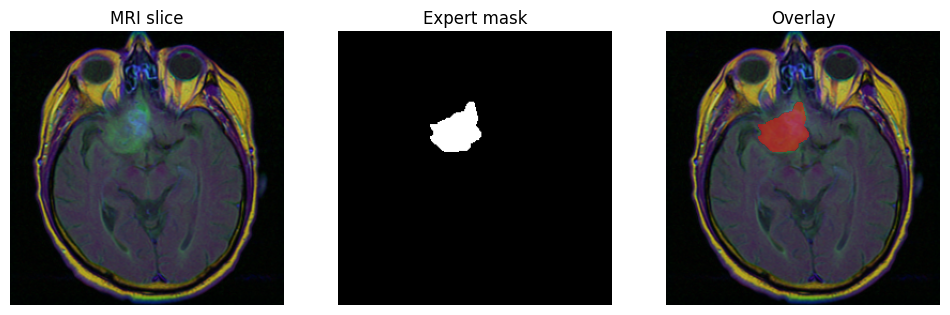

In [21]:
import cv2, numpy as np, matplotlib.pyplot as plt
has_tumour = np.array([cv2.imread(m, 0).max() > 0 for m in mask_files])
print("Slices with tumour:   ", has_tumour.sum())
print("Slices without tumour:", (~has_tumour).sum())
i = int(np.where(has_tumour)[0][0])                   # first slice with a tumour
img  = cv2.imread(image_files[i])[:, :, ::-1]         # OpenCV reads BGR -> convert to RGB
mask = cv2.imread(mask_files[i], 0)                   # 0 = read as grayscale
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img);                ax[0].set_title("MRI slice")
ax[1].imshow(mask, cmap="gray");  ax[1].set_title("Expert mask")
ax[2].imshow(img)
ax[2].imshow(np.ma.masked_where(mask == 0, mask), cmap="autumn", alpha=0.5)
ax[2].set_title("Overlay")
for a in ax: a.axis("off")
plt.show()

In [6]:
rng = np.random.default_rng(42)            # fixed seed -> same split every time
ids = np.array(sorted(set(patients)))
rng.shuffle(ids)
n = len(ids)
train_ids = set(ids[:int(0.70 * n)])
val_ids   = set(ids[int(0.70 * n):int(0.85 * n)])
test_ids  = set(ids[int(0.85 * n):])
assert not (train_ids & test_ids) and not (train_ids & val_ids)   # no shared patient
def pick(id_set):
    idx = [k for k, p in enumerate(patients) if p in id_set]
    return [image_files[k] for k in idx], [mask_files[k] for k in idx]
train_imgs, train_masks = pick(train_ids)
val_imgs,   val_masks   = pick(val_ids)
test_imgs,  test_masks  = pick(test_ids)
print(len(train_ids), len(val_ids), len(test_ids), "patients")
print(len(train_imgs), len(val_imgs), len(test_imgs), "slices")

77 16 17 patients
2714 615 600 slices


In [27]:
from torch.utils.data import Dataset, DataLoader
class MRIDataset(Dataset):
    def __init__(self, imgs, masks, augment=False):
        self.imgs, self.masks, self.augment = imgs, masks, augment

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        img  = cv2.imread(self.imgs[i])[:, :, ::-1] / 255.0
        mask = (cv2.imread(self.masks[i], 0) > 127).astype(np.float32)
        if self.augment and np.random.rand() < 0.5:
            img, mask = img[:, ::-1], mask[:, ::-1]
        img = (img - mean) / std                      # NEW: normalisation
        img = torch.tensor(img.copy(), dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask.copy()).unsqueeze(0)
        return img, mask
train_loader = DataLoader(MRIDataset(train_imgs, train_masks, augment=True),
                          batch_size=16, shuffle=True, num_workers=2)
val_loader  = DataLoader(MRIDataset(val_imgs, val_masks),   batch_size=16)
test_loader = DataLoader(MRIDataset(test_imgs, test_masks), batch_size=16)

x, y = next(iter(train_loader))
print(x.mean().item(), x.std().item())   # mean near 0, std near 1

-1.5925213098526 0.6178836226463318


In [32]:
import segmentation_models_pytorch as smp
device = "cuda"
model = smp.Unet(encoder_name="resnet34", encoder_weights=None,   # <- no pretraining
                 in_channels=3, classes=1).to(device)
dice_loss = smp.losses.DiceLoss(mode="binary")      # works directly on the raw outputs
bce_loss  = torch.nn.BCEWithLogitsLoss()
def loss_fn(logits, y):
    return dice_loss(logits, y) + bce_loss(logits, y)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [10]:
def dice_per_image(logits, y, eps=1e-6):
    pred  = (torch.sigmoid(logits) > 0.5).float()      # probability > 0.5 -> tumour
    inter = (pred * y).sum(dim=(1, 2, 3))
    total = pred.sum(dim=(1, 2, 3)) + y.sum(dim=(1, 2, 3))
    return (2 * inter + eps) / (total + eps)           # one Dice value per image
def evaluate(model, loader):
    model.eval()
    scores = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            scores.append(dice_per_image(model(x), y).cpu())
    return torch.cat(scores).numpy()

In [33]:
save_path = "/content/drive/MyDrive/unet_scratch_best.pt"
best = 0
for epoch in range(25):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        loss = loss_fn(model(x), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    val_dice = evaluate(val_loader).mean()
    print(f"epoch {epoch+1:2d} | last loss {loss.item():.3f} | val Dice {val_dice:.3f}")
    if val_dice > best:
        best = val_dice
        torch.save(model.state_dict(), save_path)       # saved to Drive

epoch  1 | last loss 1.143 | val Dice 0.524
epoch  2 | last loss 0.953 | val Dice 0.654
epoch  3 | last loss 0.912 | val Dice 0.674
epoch  4 | last loss 0.612 | val Dice 0.732
epoch  5 | last loss 0.376 | val Dice 0.746
epoch  6 | last loss 0.415 | val Dice 0.755
epoch  7 | last loss 0.213 | val Dice 0.754
epoch  8 | last loss 0.591 | val Dice 0.783
epoch  9 | last loss 0.245 | val Dice 0.803
epoch 10 | last loss 0.468 | val Dice 0.794
epoch 11 | last loss 0.131 | val Dice 0.784
epoch 12 | last loss 0.137 | val Dice 0.773
epoch 13 | last loss 0.119 | val Dice 0.786
epoch 14 | last loss 0.402 | val Dice 0.762
epoch 15 | last loss 0.266 | val Dice 0.808
epoch 16 | last loss 0.139 | val Dice 0.786
epoch 17 | last loss 0.143 | val Dice 0.808
epoch 18 | last loss 0.050 | val Dice 0.804
epoch 19 | last loss 0.127 | val Dice 0.772
epoch 20 | last loss 0.093 | val Dice 0.767
epoch 21 | last loss 0.139 | val Dice 0.794
epoch 22 | last loss 0.166 | val Dice 0.798
epoch 23 | last loss 0.152 | val

Dice, all test slices:    0.886
Dice, tumour slices only: 0.700
IoU,  tumour slices only: 0.538


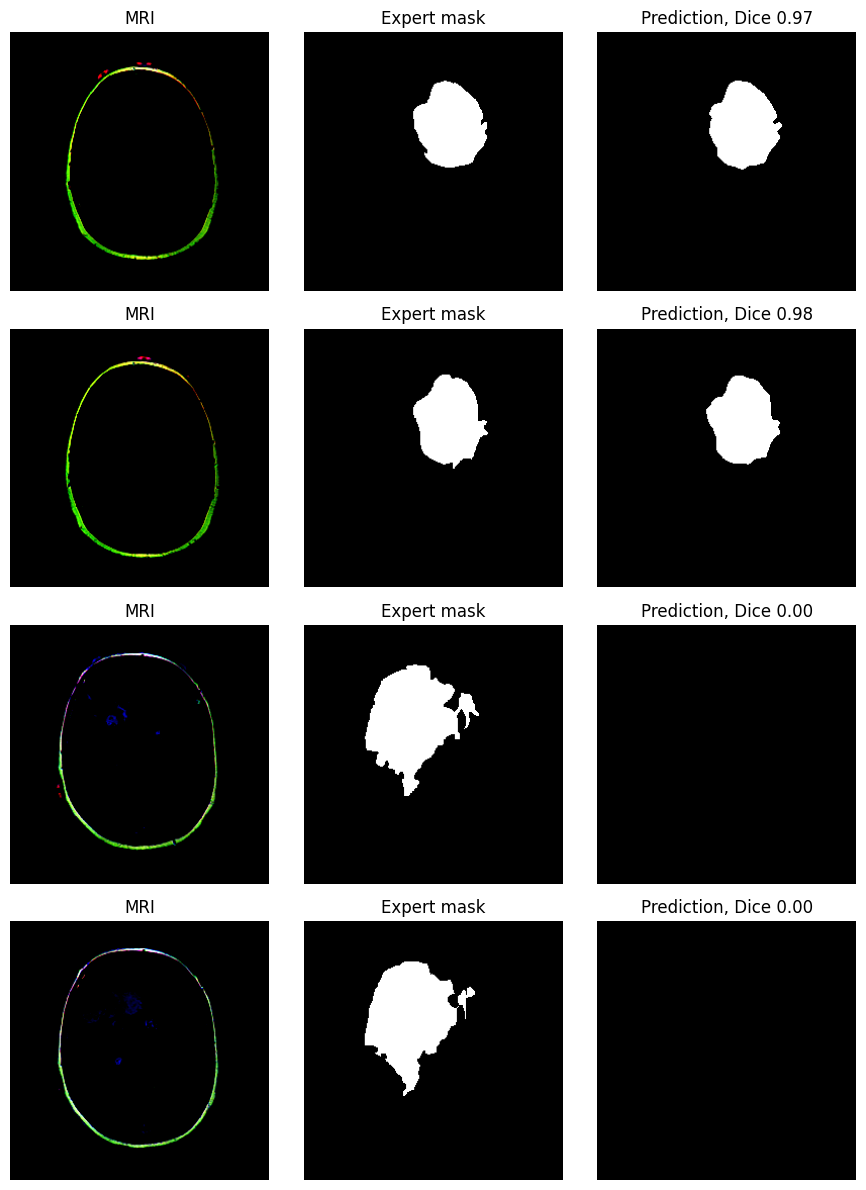

In [34]:
model.load_state_dict(torch.load(save_path))
scores = evaluate(test_loader)
tumour = np.array([cv2.imread(m, 0).max() > 0 for m in test_masks])
print(f"Dice, all test slices:    {scores.mean():.3f}")
print(f"Dice, tumour slices only: {scores[tumour].mean():.3f}")
d = scores[tumour].mean()
print(f"IoU,  tumour slices only: {d / (2 - d):.3f}")    # approximate, from mean Dice test_ds = MRIDataset(test_imgs, test_masks)
test_ds = MRIDataset(test_imgs, test_masks)
worst = np.where(tumour)[0][np.argsort(scores[tumour])[:2]]    # 2 worst tumour slices
best_ = np.where(tumour)[0][np.argsort(scores[tumour])[-2:]]   # 2 best tumour slices
rows = list(best_) + list(worst)
model.eval()
fig, ax = plt.subplots(len(rows), 3, figsize=(9, 3 * len(rows)))
for r, k in enumerate(rows):
    x, y = test_ds[k]
    with torch.no_grad():
        p = torch.sigmoid(model(x[None].to(device)))[0, 0].cpu() > 0.5
    ax[r, 0].imshow(x.permute(1, 2, 0)); ax[r, 0].set_title("MRI")
    ax[r, 1].imshow(y[0], cmap="gray");  ax[r, 1].set_title("Expert mask")
    ax[r, 2].imshow(p, cmap="gray");     ax[r, 2].set_title(f"Prediction, Dice {scores[k]:.2f}")
    for a in ax[r]: a.axis("off")
plt.tight_layout(); plt.savefig("predictions.png", dpi=120); plt.show()

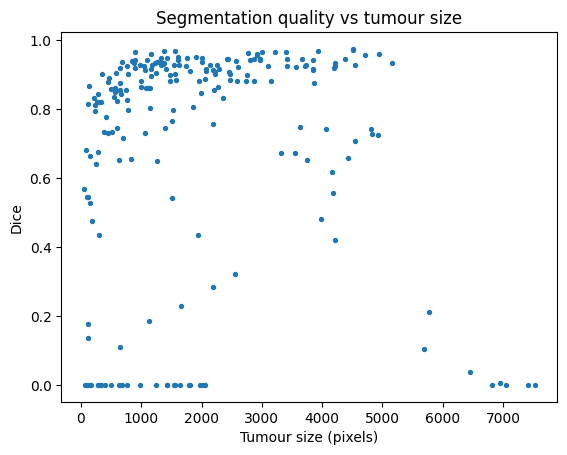

small  tumours: mean Dice = 0.609 | completely missed (Dice < 0.01) = 20%
medium tumours: mean Dice = 0.717 | completely missed (Dice < 0.01) = 15%
large  tumours: mean Dice = 0.770 | completely missed (Dice < 0.01) = 7%
threshold 0.5: val Dice (tumour slices) = 0.527
threshold 0.4: val Dice (tumour slices) = 0.529
threshold 0.3: val Dice (tumour slices) = 0.531
threshold 0.2: val Dice (tumour slices) = 0.533


In [35]:
sizes = np.array([(cv2.imread(m, 0) > 127).sum() for m in test_masks])

plt.scatter(sizes[tumour], scores[tumour], s=8)
plt.xlabel("Tumour size (pixels)"); plt.ylabel("Dice")
plt.title("Segmentation quality vs tumour size")
plt.savefig("dice_vs_tumour_size.png", dpi=120)
plt.show()

# Average Dice for small / medium / large tumours
s, d = sizes[tumour], scores[tumour]
cuts = np.percentile(s, [0, 33, 66, 100])
for i, name in enumerate(["small", "medium", "large"]):
    m = (s >= cuts[i]) & (s <= cuts[i + 1])
    print(f"{name:6s} tumours: mean Dice = {d[m].mean():.3f} | "
          f"completely missed (Dice < 0.01) = {(d[m] < 0.01).mean() * 100:.0f}%")


# ------------------------------------------------------------
# CELL 2: does a LOWER THRESHOLD help?
# Important: we test it on the VALIDATION set, not the test set.
# (Your guide says: never choose anything using the test set.)
# ------------------------------------------------------------
def dice_at_threshold(loader, thr):
    model.eval()
    out = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            p = (torch.sigmoid(model(x)) > thr).float()
            inter = (p * y).sum(dim=(1, 2, 3))
            total = p.sum(dim=(1, 2, 3)) + y.sum(dim=(1, 2, 3))
            out.append(((2 * inter + 1e-6) / (total + 1e-6)).cpu())
    return torch.cat(out).numpy()

val_tumour = np.array([cv2.imread(m, 0).max() > 0 for m in val_masks])

for thr in [0.5, 0.4, 0.3, 0.2]:
    sc = dice_at_threshold(val_loader, thr)
    print(f"threshold {thr}: val Dice (tumour slices) = {sc[val_tumour].mean():.3f}")

# If a lower threshold is clearly better on validation, pick it,
# then report the test score ONE time with that threshold:
# best_thr = 0.3
# sc_test = dice_at_threshold(test_loader, best_thr)
# print("Test Dice, tumour slices:", sc_test[tumour].mean())


# ------------------------------------------------------------
# CELL 3: THE FIX -> a loss that punishes missed tumours more
# Run this cell, then redo Step 6, Step 8 and Step 9.
# ------------------------------------------------------------
def focal_tversky_loss(logits, y, alpha=0.7, beta=0.3, gamma=0.75, eps=1e-6):
    p = torch.sigmoid(logits)
    tp = (p * y).sum(dim=(1, 2, 3))          # tumour found
    fn = ((1 - p) * y).sum(dim=(1, 2, 3))    # tumour MISSED (punished more)
    fp = (p * (1 - y)).sum(dim=(1, 2, 3))    # false alarm
    tversky = (tp + eps) / (tp + alpha * fn + beta * fp + eps)
    return ((1 - tversky) ** gamma).mean()

def loss_fn(logits, y):                       # replaces the old loss_fn of Step 6
    return focal_tversky_loss(logits, y) + bce_loss(logits, y)

In [19]:
scores_base = scores.copy()

In [26]:
params = smp.encoders.get_preprocessing_params("resnet34")
mean, std = np.array(params["mean"]), np.array(params["std"])
print(mean, std)

[0.485 0.456 0.406] [0.229 0.224 0.225]


In [36]:
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                 in_channels=3, classes=1).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/unet_pretrained_norm_best.pt"))

scores_pre = evaluate(test_loader)
tumour = np.array([cv2.imread(m, 0).max() > 0 for m in test_masks])
print(f"Pretrained+norm: all {scores_pre.mean():.3f} | tumour {scores_pre[tumour].mean():.3f}")

Pretrained+norm: all 0.902 | tumour 0.736
